In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('job_salary_prediction_dataset.csv')

## Analyzing Data

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   job_title         250000 non-null  str  
 1   experience_years  250000 non-null  int64
 2   education_level   250000 non-null  str  
 3   skills_count      250000 non-null  int64
 4   industry          250000 non-null  str  
 5   company_size      250000 non-null  str  
 6   location          250000 non-null  str  
 7   remote_work       250000 non-null  str  
 8   certifications    250000 non-null  int64
 9   salary            250000 non-null  int64
dtypes: int64(4), str(6)
memory usage: 19.1 MB


In [4]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.isnull().sum()

job_title           0
experience_years    0
education_level     0
skills_count        0
industry            0
company_size        0
location            0
remote_work         0
certifications      0
salary              0
dtype: int64

In [7]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='str')

In [8]:
df['education_level'].unique()

<StringArray>
['Bachelor', 'PhD', 'High School', 'Diploma', 'Master']
Length: 5, dtype: str

In [9]:
df['certifications'].unique()

array([2, 0, 1, 3, 5, 4])

In [10]:
df['skills_count'].unique()

array([ 2, 17,  4, 13,  7, 16, 18, 14, 10,  3,  5,  9,  1, 12, 15,  8, 19,
       11,  6])

In [11]:
df['industry'].unique()

<StringArray>
[   'Healthcare',       'Telecom',         'Media',        'Retail',
 'Manufacturing',     'Education',       'Finance',    'Technology',
    'Consulting',    'Government']
Length: 10, dtype: str

In [12]:
df['job_title'].unique()

<StringArray>
[              'AI Engineer',              'Data Analyst',
        'Frontend Developer',          'Business Analyst',
           'Product Manager',         'Backend Developer',
 'Machine Learning Engineer',           'DevOps Engineer',
         'Software Engineer',     'Cybersecurity Analyst',
            'Data Scientist',            'Cloud Engineer']
Length: 12, dtype: str

In [13]:
df['remote_work'].unique()

<StringArray>
['Hybrid', 'No', 'Yes']
Length: 3, dtype: str

In [14]:
df['location'].unique()

<StringArray>
[      'India',   'Australia',   'Singapore',      'Canada',      'Sweden',
         'USA', 'Netherlands',      'Remote',     'Germany',          'UK']
Length: 10, dtype: str

## Visualizing Data

In [15]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='str')

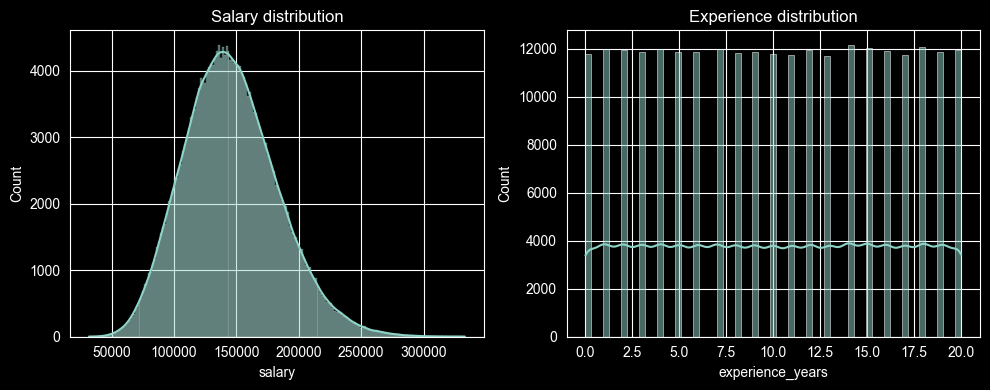

In [16]:
fig, ax = plt.subplots(1, 2, figsize=(10,4))
sns.histplot(df['salary'], kde=True, ax=ax[0])
ax[0].set_title('Salary distribution')
sns.histplot(df['experience_years'], kde=True, ax=ax[1])
ax[1].set_title('Experience distribution')
plt.tight_layout()

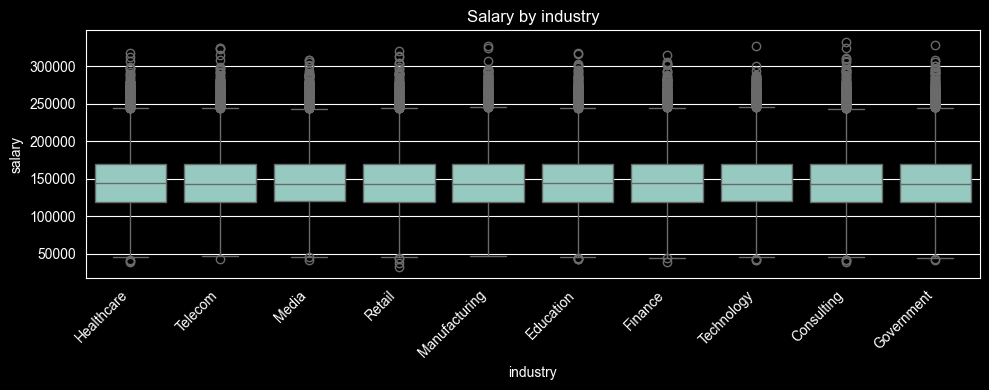

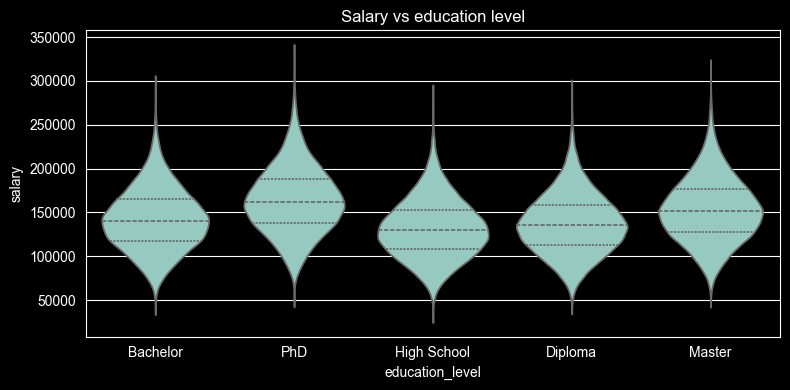

In [17]:
plt.figure(figsize=(10,4))
sns.boxplot(data=df, x='industry', y='salary')
plt.xticks(rotation=45, ha='right')
plt.title('Salary by industry')
plt.tight_layout()

plt.figure(figsize=(8,4))
sns.violinplot(data=df, x='education_level', y='salary', inner='quartile')
plt.title('Salary vs education level')
plt.tight_layout()

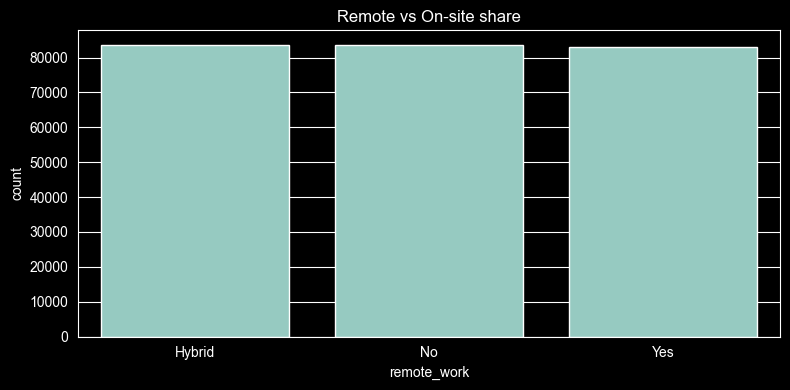

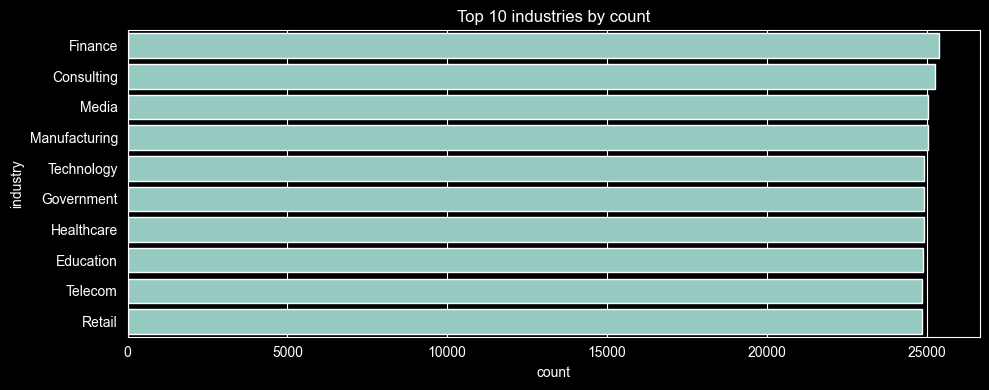

In [18]:
plt.figure(figsize=(8,4))
sns.countplot(data=df, x='remote_work')
plt.title('Remote vs On-site share')
plt.tight_layout()

top_industries = df['industry'].value_counts().nlargest(10).index
plt.figure(figsize=(10,4))
sns.countplot(data=df[df['industry'].isin(top_industries)], y='industry',
              order=top_industries)
plt.title('Top 10 industries by count')
plt.tight_layout()

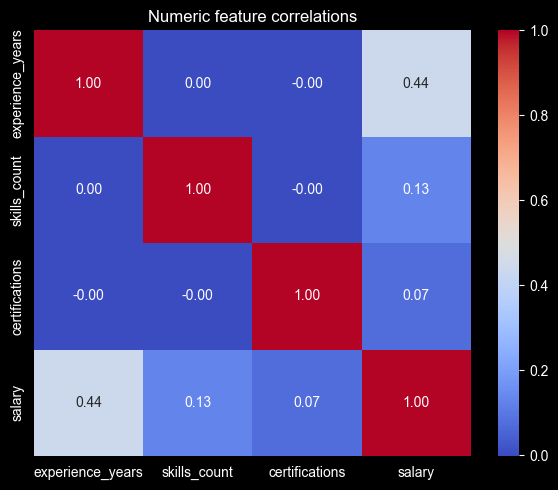

In [19]:
num_cols = ['experience_years','skills_count','certifications','salary']
corr = df[num_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Numeric feature correlations')
plt.tight_layout()

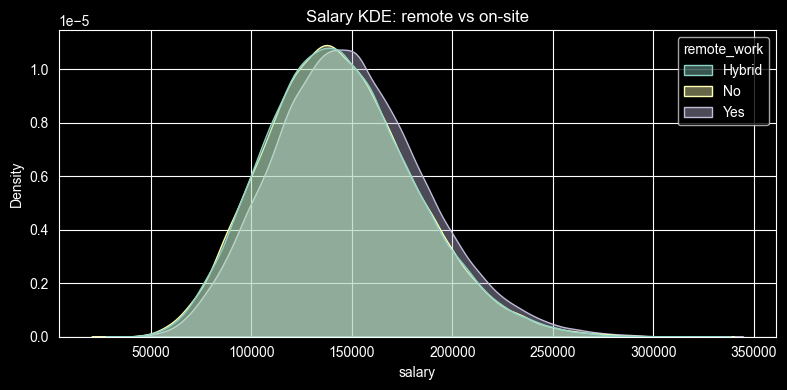

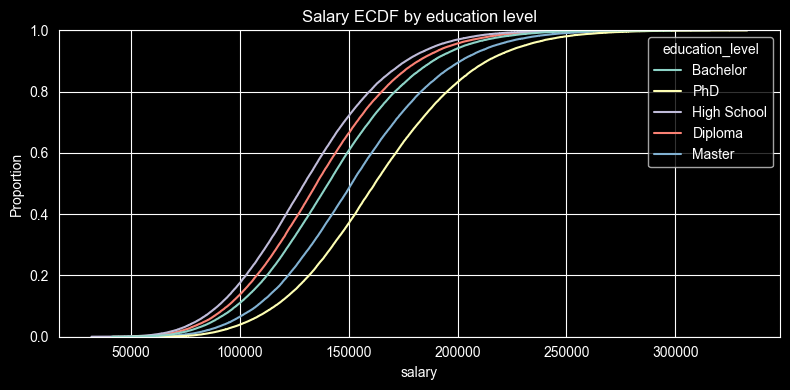

In [20]:
plt.figure(figsize=(8,4))
sns.kdeplot(data=df, x='salary', hue='remote_work', common_norm=False, fill=True, alpha=0.4)
plt.title('Salary KDE: remote vs on-site')
plt.tight_layout()

plt.figure(figsize=(8,4))
sns.ecdfplot(data=df, x='salary', hue='education_level')
plt.title('Salary ECDF by education level')
plt.tight_layout()

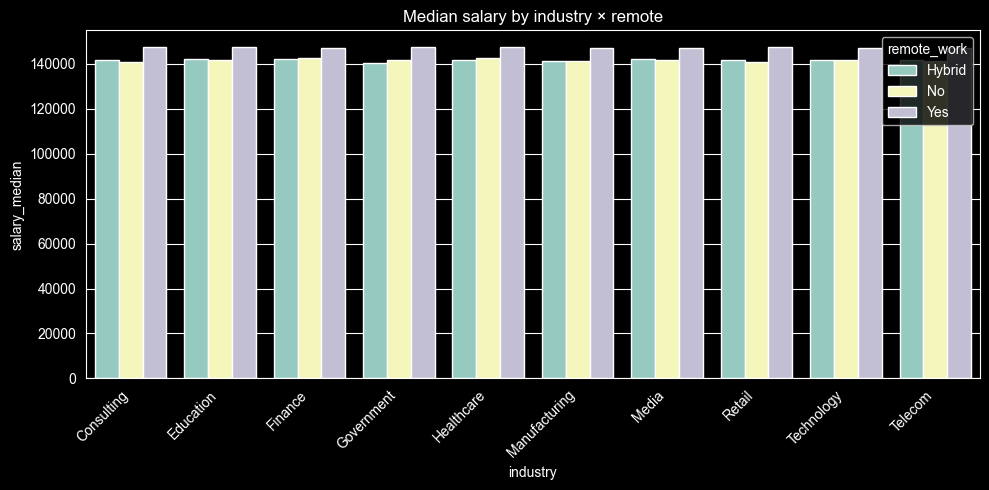

In [21]:
agg = (df.groupby(['industry','remote_work'])['salary']
         .median()
         .reset_index()
         .rename(columns={'salary':'salary_median'}))
plt.figure(figsize=(10,5))
sns.barplot(data=agg, x='industry', y='salary_median', hue='remote_work')
plt.xticks(rotation=45, ha='right')
plt.title('Median salary by industry × remote')
plt.tight_layout()

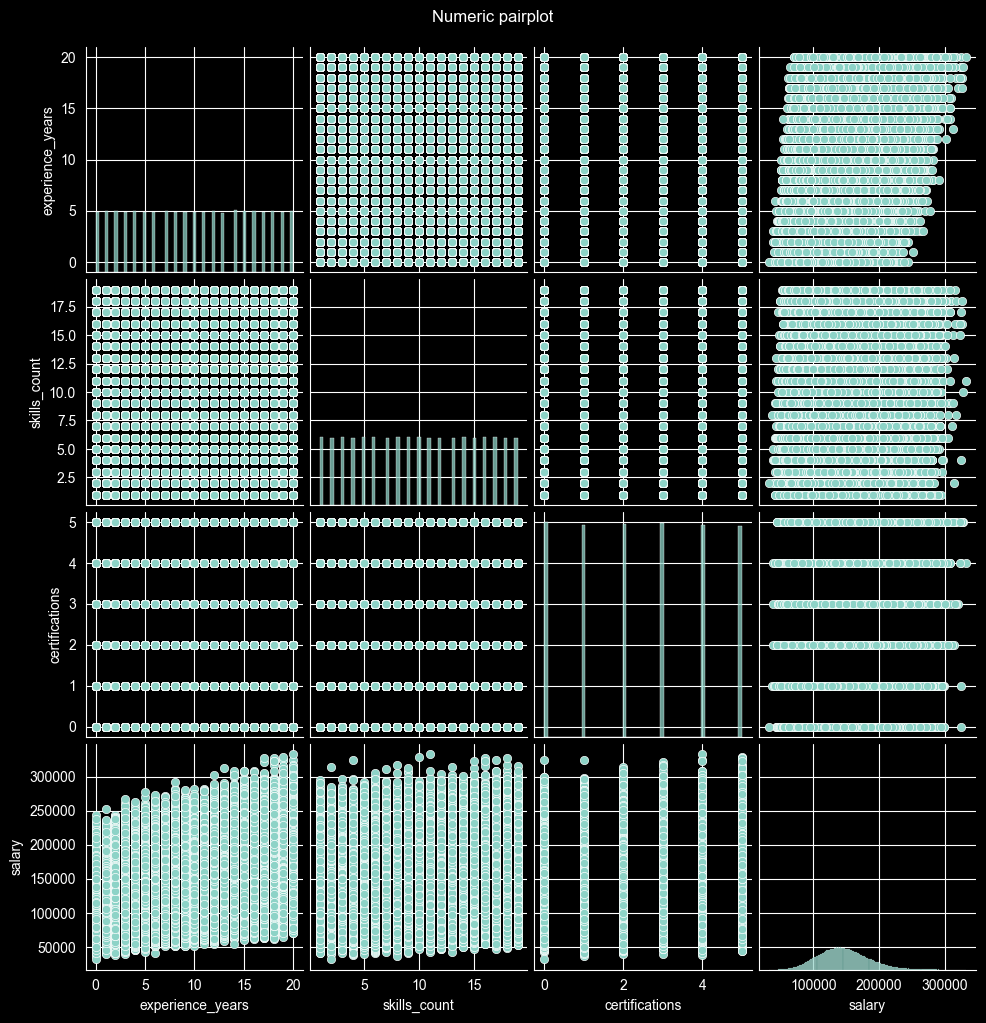

In [22]:
sns.pairplot(df[num_cols], diag_kind='hist')
plt.suptitle('Numeric pairplot', y=1.02)
plt.show()

## Feature Engineering

In [23]:
df.columns

Index(['job_title', 'experience_years', 'education_level', 'skills_count',
       'industry', 'company_size', 'location', 'remote_work', 'certifications',
       'salary'],
      dtype='str')

In [24]:
df['experience_years'].unique()

array([10,  5, 18, 19, 15,  0,  6,  4,  1,  8,  3, 14, 11,  9, 17, 12, 13,
        2,  7, 20, 16])

### Creating new features

In [25]:
df['advanced_dev'] = (df['experience_years'] >= 9) & (df['skills_count'] > 12)

In [26]:
df.head()

,job_title,experience_years,education_level,skills_count,industry,company_size,location,remote_work,certifications,salary,advanced_dev
0,AI Engineer,10,Bachelor,2,Healthcare,Medium,India,Hybrid,2,109413,False
1,Data Analyst,5,Bachelor,17,Telecom,Small,Australia,No,0,93764,False
2,Frontend Developer,18,PhD,4,Media,Medium,Singapore,No,1,148123,False
3,Business Analyst,19,PhD,13,Retail,Medium,Canada,Yes,0,189123,True
4,Product Manager,15,Bachelor,7,Manufacturing,Large,Sweden,Yes,0,165069,False


### Encoding

In [27]:
df = pd.get_dummies(df, drop_first=True)

In [28]:
df.head()

,experience_years,skills_count,certifications,salary,advanced_dev,job_title_Backend Developer,job_title_Business Analyst,job_title_Cloud Engineer,job_title_Cybersecurity Analyst,job_title_Data Analyst,...,location_Germany,location_India,location_Netherlands,location_Remote,location_Singapore,location_Sweden,location_UK,location_USA,remote_work_No,remote_work_Yes
0,10,2,2,109413,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,False,False
1,5,17,0,93764,False,False,False,False,False,True,...,False,False,False,False,False,False,False,False,True,False
2,18,4,1,148123,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,True,False
3,19,13,0,189123,True,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,15,7,0,165069,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True


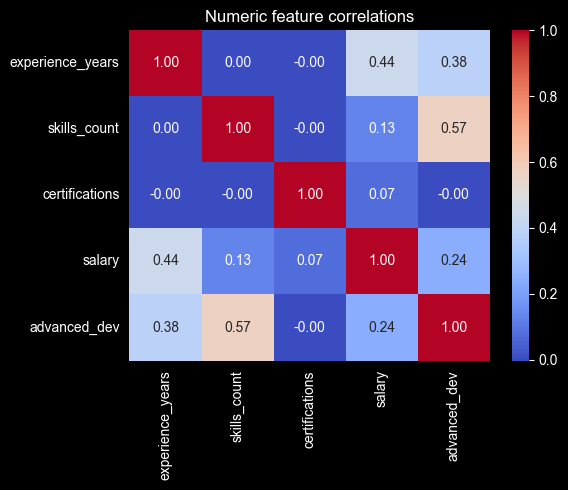

In [29]:
num_cols = ['experience_years', 'skills_count', 'certifications', 'salary', 'advanced_dev']
corr = df[num_cols].corr()
plt.figure(figsize=(6,5))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Numeric feature correlations')
plt.tight_layout()

## Splitting Data

In [30]:
from sklearn.model_selection import train_test_split

In [31]:
X = df.drop(columns=['salary'])

In [32]:
y = df['salary']

In [33]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

## Building Model

In [34]:
from sklearn.linear_model import LinearRegression

In [35]:
model = LinearRegression()

In [36]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [37]:
model.coef_

array([ 2.69902242e+03,  8.55170929e+02,  1.61946351e+03,  3.26009832e+01,
       -3.42905415e+04, -5.15070678e+04, -2.14783319e+04, -2.46980347e+04,
       -5.37365315e+04, -2.68976655e+04, -2.36676718e+04, -4.08646107e+04,
       -1.06617204e+04, -1.60898589e+04, -3.22325447e+04, -5.38222603e+03,
       -1.07428436e+04,  1.08249664e+04,  2.15301963e+04,  4.11363969e+01,
        6.90569659e+01,  1.35622114e+02,  1.00947611e+02, -2.69628095e+01,
        1.07675643e+02,  9.53082821e+01,  8.80740050e+01,  2.31764108e+01,
       -1.41128309e+04, -2.82697502e+04, -3.53934248e+04, -4.24168212e+04,
        2.78869439e+04,  1.39603168e+04, -4.19038031e+04, -5.77490059e+01,
       -3.09484665e+01, -4.77671337e+00, -5.19935692e+01,  2.09175336e+04,
        4.19814520e+04, -9.85240240e-01,  5.32619036e+03])

In [38]:
model.intercept_

np.float64(146766.19692610338)

In [39]:
model.get_params()

{'copy_X': True,
 'fit_intercept': True,
 'n_jobs': None,
 'positive': False,
 'tol': 1e-06}

## Predictions

In [40]:
y_pred = model.predict(X_test)

In [41]:
y_pred

array([172793.32977068,  89212.22474936,  63800.344173  , ...,
       137504.98420131,  94450.99183357,  89389.41375575], shape=(82500,))

## Evaluation

In [42]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

### R2-Score

In [43]:
r2_score(y_test, y_pred)

0.9632431390548664

### MAE

In [44]:
mean_absolute_error(y_test, y_pred)

5464.935927099587

### MSE

In [45]:
mean_squared_error(y_test, y_pred)

51274213.5179633

### RMSE

In [46]:
root_mean_squared_error(y_test, y_pred)

7160.601477387448